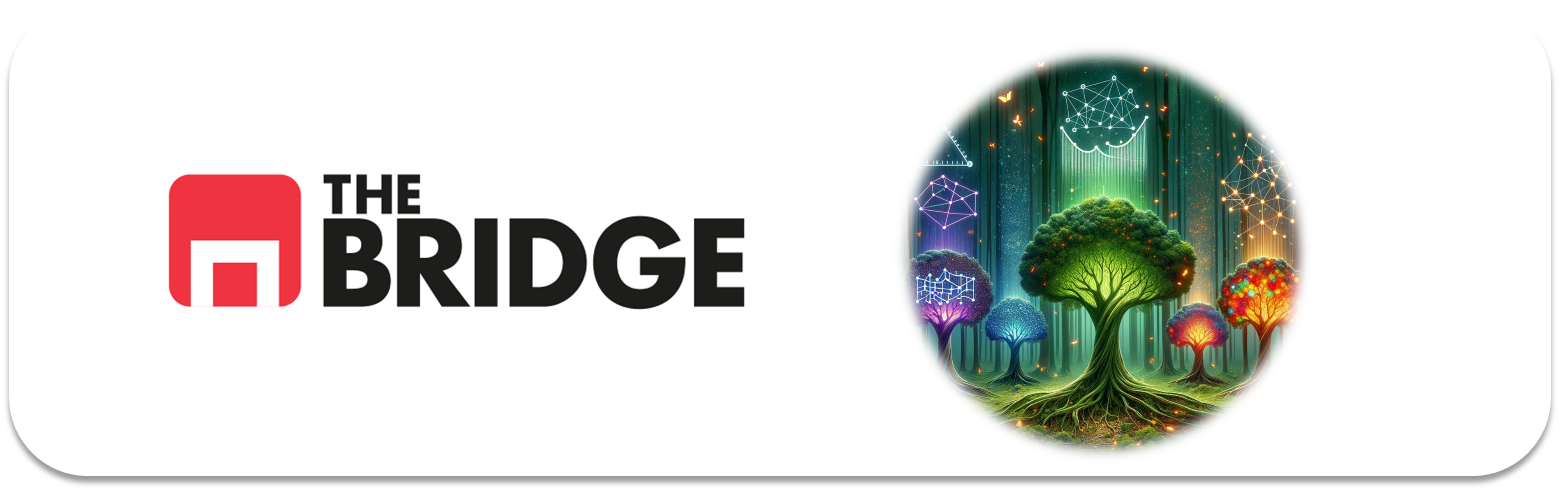

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [2]:
df = pd.read_csv("./data/bank-full.csv", sep=";")  # ojo, separador punto y coma
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
for col in df.columns:
    print(f"{col}:", end=" ")
    try:
        missings = df[col].value_counts()["unknown"]
        print(f"{missings} unknowns ({round(missings/len(df)*100, 2)}%)")
    except:
        print(0)

age: 0
job: 288 unknowns (0.64%)
marital: 0
education: 1857 unknowns (4.11%)
default: 0
balance: 0
housing: 0
loan: 0
contact: 13020 unknowns (28.8%)
day: 0
month: 0
duration: 0
campaign: 0
pdays: 0
previous: 0
poutcome: 36959 unknowns (81.75%)
y: 0


In [5]:
target = "y"  # el banco quiere saber si el cliente pica o no

In [6]:
df[target].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

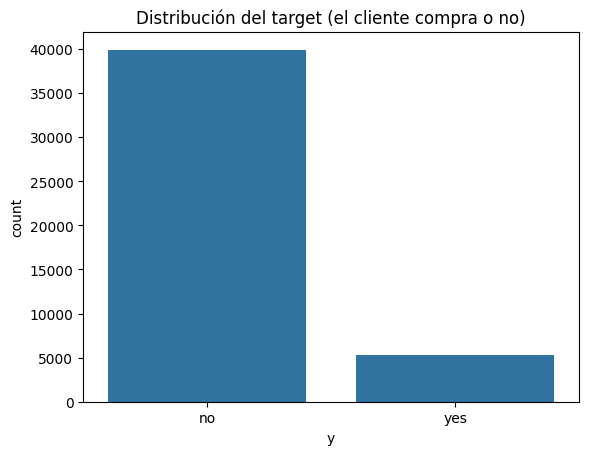

In [7]:
sns.countplot(data=df, x=target)
plt.title("Distribución del target (el cliente compra o no)")
plt.show()
# ~88% no compra, desequilibrado

In [8]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)  # 20% para test
print(train_set.shape, test_set.shape)

(36168, 17) (9043, 17)


In [9]:
# Separar features categóricas y numéricas
features_cat = train_set.select_dtypes(include="object").columns.to_list()
if target in features_cat:
    features_cat.remove(target)

features_num = [col for col in train_set.columns if col not in features_cat and col != target]

print("Categóricas:", features_cat)
print("Numéricas:", features_num)

Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


/tmp/ipykernel_8818/916012841.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  features_cat = train_set.select_dtypes(include="object").columns.to_list()


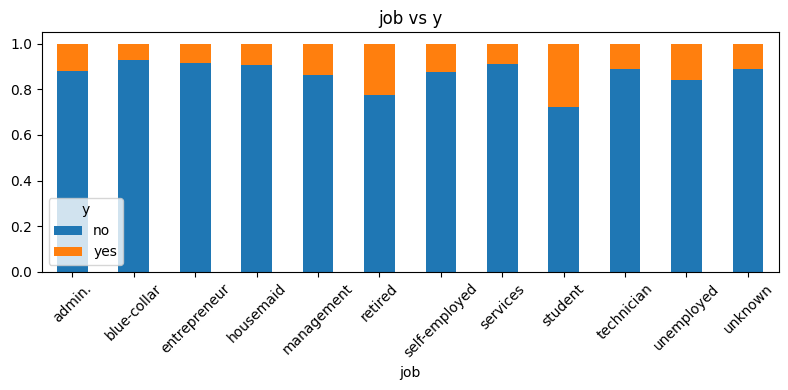

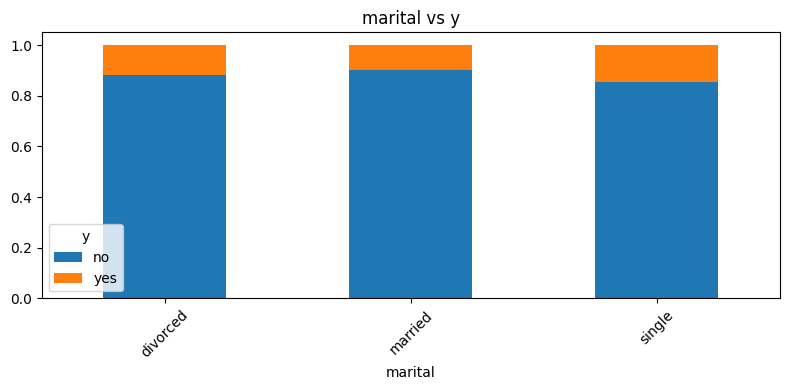

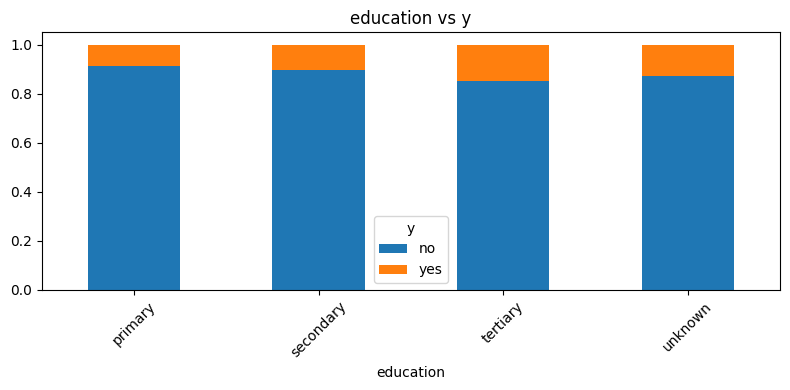

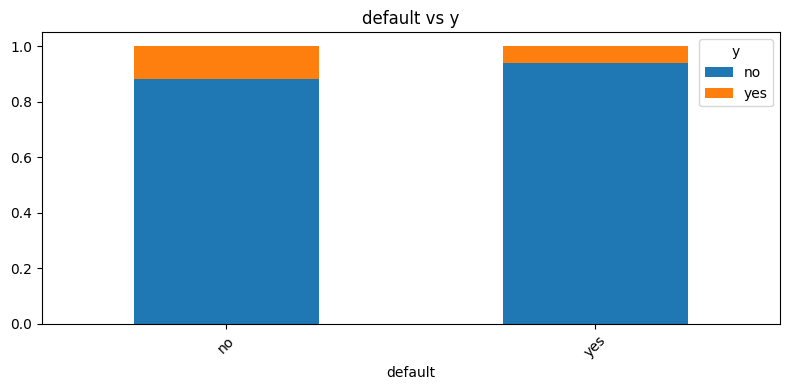

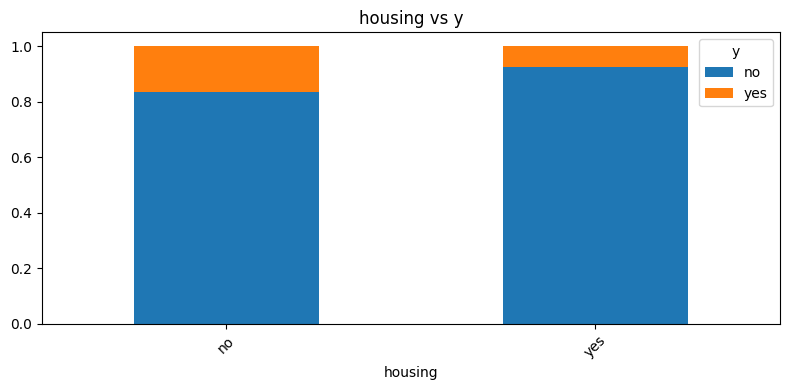

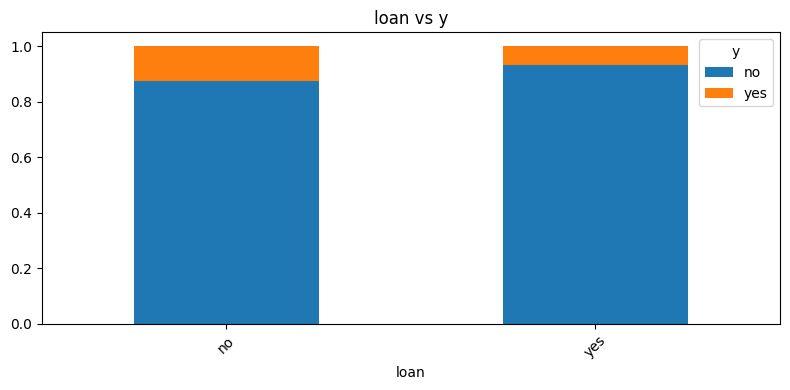

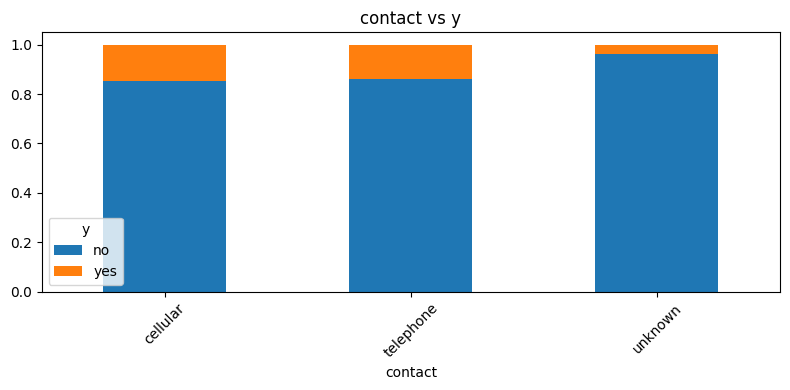

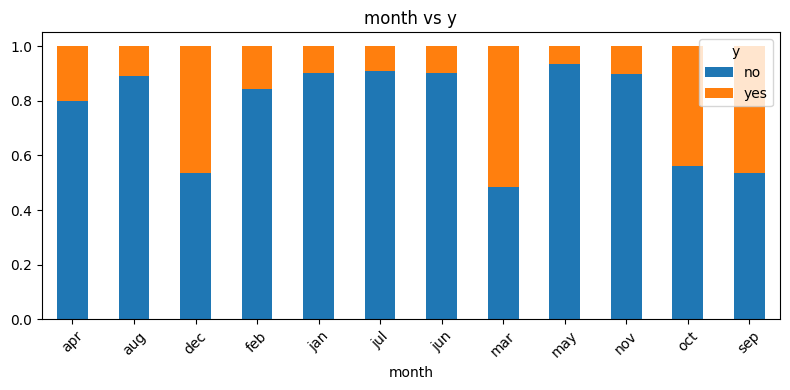

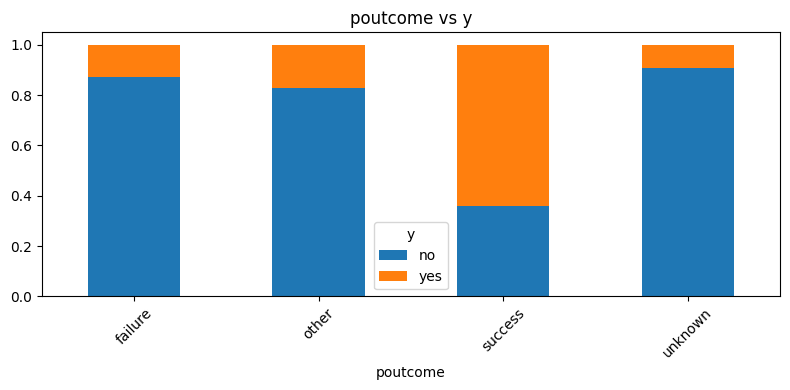

In [10]:
for col in features_cat:
    ct = pd.crosstab(train_set[col], train_set[target], normalize="index")
    ct.plot(kind="bar", stacked=True, figsize=(8, 4), title=f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
# 'default' no discrimina nada, la quitamos

In [11]:
features_cat.remove("default")

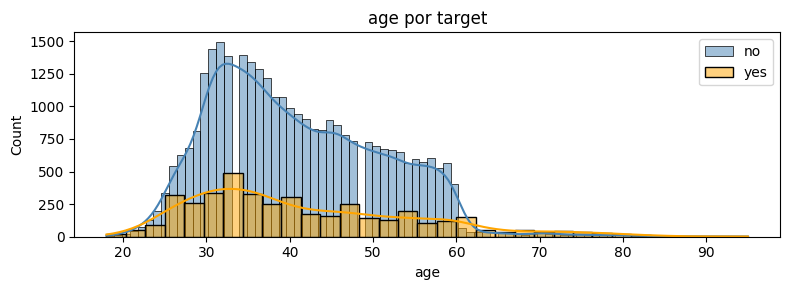

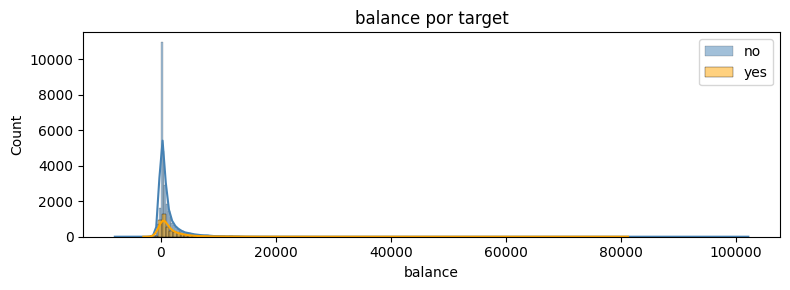

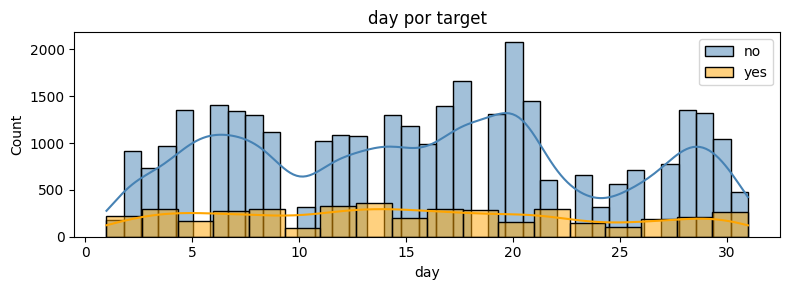

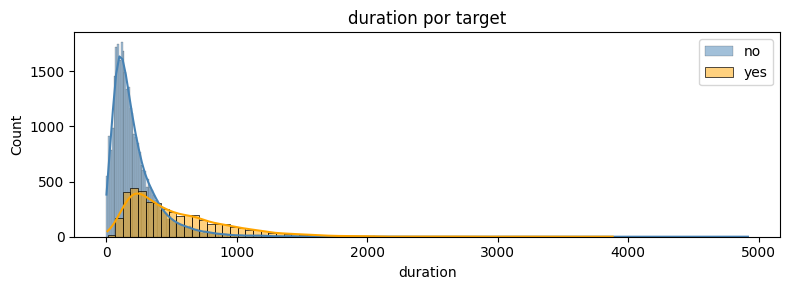

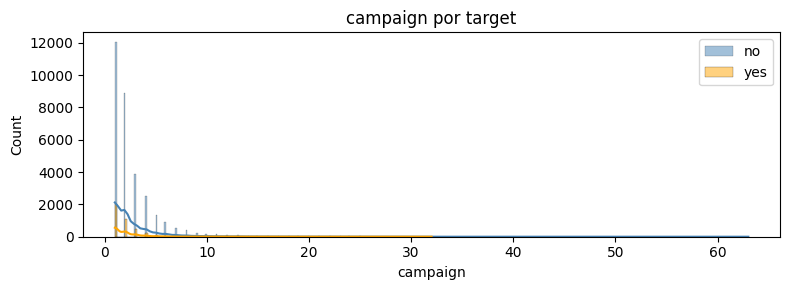

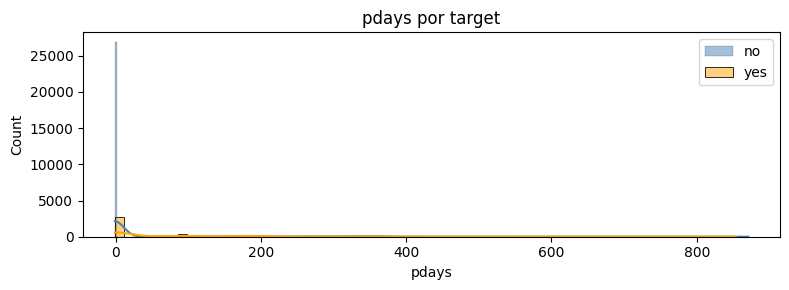

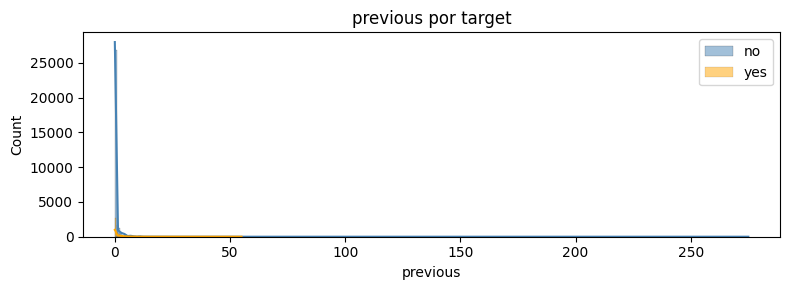

In [12]:
for col in features_num: # No va?
    plt.figure(figsize=(8, 3))
    sns.histplot(train_set[train_set[target] == "no"][col], kde=True, label="no", color="steelblue")
    sns.histplot(train_set[train_set[target] == "yes"][col], kde=True, label="yes", color="orange")
    plt.title(f"{col} por target")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
train_set["housing"] = train_set["housing"] == "yes"
train_set["loan"]    = train_set["loan"] == "yes"
test_set["housing"]  = test_set["housing"] == "yes"
test_set["loan"]     = test_set["loan"] == "yes"

features_cat.remove("housing")
features_cat.remove("loan")

In [14]:
month_dic = {"jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
             "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}

train_set["month"] = train_set["month"].map(month_dic)
test_set["month"]  = test_set["month"].map(month_dic)

features_cat.remove("month")

In [15]:
train_set["contacted_before"] = train_set["pdays"] != -1
test_set["contacted_before"]  = test_set["pdays"] != -1

In [16]:
train_set = pd.get_dummies(train_set, columns=features_cat, dtype=int)
test_set  = pd.get_dummies(test_set,  columns=features_cat, dtype=int)

print(train_set.shape, test_set.shape)

(36168, 39) (9043, 39)


In [17]:
# Asegurarse de que train y test tienen las mismas columnas
columnas_extra_train = train_set.columns[~train_set.columns.isin(test_set.columns)]
print("Columnas en train pero no en test:", columnas_extra_train.tolist())

Columnas en train pero no en test: []


In [18]:
train_set_scaled = train_set.copy()
test_set_scaled  = test_set.copy()

train_set_scaled["balance"]  = np.cbrt(train_set_scaled["balance"])   # raíz cúbica por valores negativos
train_set_scaled["duration"] = np.log(train_set_scaled["duration"] + 1)
train_set_scaled["campaign"] = np.log(train_set_scaled["campaign"])
train_set_scaled["pdays"]    = np.log(train_set_scaled["pdays"] + 2)  # +2 por el -1
train_set_scaled["previous"] = np.log(train_set_scaled["previous"] + 1)

test_set_scaled["balance"]   = np.cbrt(test_set_scaled["balance"])
test_set_scaled["duration"]  = np.log(test_set_scaled["duration"] + 1)
test_set_scaled["campaign"]  = np.log(test_set_scaled["campaign"])
test_set_scaled["pdays"]     = np.log(test_set_scaled["pdays"] + 2)
test_set_scaled["previous"]  = np.log(test_set_scaled["previous"] + 1)

In [19]:
scaler = StandardScaler()

train_set_scaled[features_num] = scaler.fit_transform(train_set_scaled[features_num])  # fit solo en train
test_set_scaled[features_num]  = scaler.transform(test_set_scaled[features_num])

In [20]:
feature_cols = [col for col in train_set.columns if col != target] #kernel empantallao ya

X_train        = train_set[feature_cols].copy()
X_train_scaled = train_set_scaled[feature_cols].copy()
y_train        = train_set[target]

X_test        = test_set[feature_cols].copy()
X_test_scaled = test_set_scaled[feature_cols].copy()
y_test        = test_set[target]

In [21]:
lr_clf   = LogisticRegression(max_iter=1000)
tree_clf = DecisionTreeClassifier(random_state=42)  # sin límites

In [22]:
# Entrenamos la logística
lr_clf.fit(X_train_scaled, y_train)
print("=== Logística - Train ===")
print(classification_report(y_train, lr_clf.predict(X_train_scaled)))

ValueError: could not convert string to float: 'no'